# Question 1

### Question b

                -2.142  -1.071   0.000   1.071   2.142  row_sum
current → next                                                 
-2.142          0.6376  0.2729  0.0753  0.0129  0.0013   1.0000
-1.071          0.1735  0.4000  0.3247  0.0926  0.0092   1.0000
0.000           0.0507  0.2439  0.4108  0.2439  0.0507   1.0000
1.071           0.0092  0.0926  0.3247  0.4000  0.1735   1.0000
2.142           0.0001  0.0020  0.0246  0.1791  0.7941   0.9999
Simulated z_t:
 [-2.14242853  0.         -1.07121426 ...  2.14242853  2.14242853
  2.14242853]


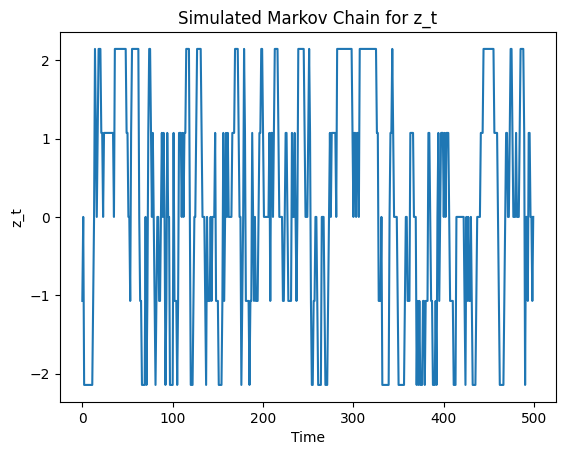

Mean of simulation: 0.27922985155602553
Standard deviation of simulation : 1.4454326999206846
Autocorrelation of simulation (lag 1): 0.8015601094090784
Theoretical Mean: 0
Theoretical Standard Deviation: 0.51
Theoretical Autocorrelation (lag 1): 0.7


In [138]:
import numpy as np
from numpy import sqrt
from scipy.stats import norm
import matplotlib.pyplot as plt
import pandas as pd
from math import comb
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt


# Parameters 
# Ar(1) process z_t+1 = rho*z_t + (1- rho^2) epsilon_t+1 where epsilon ~ N(0,1)
rho = 0.7
m= 3
N = 5
T = 2000 
mean_z = 0
sigma_epsilon = 1
sigma_z = (1-rho**2)

# Tauchen method 
# Creating state space for (slide 28)
Z_N = m * sqrt(sigma_z)
Z_1 = - Z_N
d = (Z_N - Z_1) / (N - 1)
z_grid = np.linspace(Z_1, Z_N, N)

# Transition matrix (slide 29)
P = np.zeros((N, N))
P_i1 = norm.cdf((z_grid[0] - rho * z_grid + d / 2) / sigma_epsilon) # First row
P_iN = 1 - norm.cdf((z_grid[-1] - rho * z_grid + d / 2) / sigma_epsilon) # Last row
P_ij = np.zeros((N-2, N)) # Middle rows 
for i in range(1, N-1):
    for j in range(N):
        P_ij[i-1, j] = norm.cdf((z_grid[j] - rho * z_grid[i] + d / 2) / sigma_epsilon) - norm.cdf((z_grid[j] - rho * z_grid[i] - d / 2) / sigma_epsilon)

P[0, :] = P_i1
P[-1, :] = P_iN
P[1:-1, :] = P_ij

# Create table by using function (see below)
dfP = transition_table(z_grid, P, decimals=4)
print(dfP)

P = P / P.sum(axis=1, keepdims=True) # Normalize rows to sum to 1

# Simulate Markov Chain 
z_sim = np.zeros(T)
z_sim[0] = Z_1  # Start at the lowest state
cdf = np.cumsum(P, axis=1)
cdf[:, -1] = 1.0

z_sim = np.empty(T)
idx = 0  # 0..N-1; e.g., 0 for lowest state
z_sim[0] = z_grid[idx]

u = np.random.rand(T-1)  # in [0,1)
for t in range(1, T):
    idx = np.searchsorted(cdf[idx], u[t-1], side="right")
    z_sim[t] = z_grid[idx]
print("Simulated z_t:\n", z_sim)

# Discard first 500 observations 
z_sim = z_sim[500:]

# Plot the simulated series
plt.plot(z_sim[:500]) #Only first 500 for better visibility
plt.title('Simulated Markov Chain for z_t')
plt.xlabel('Time')
plt.ylabel('z_t')
plt.show()
 
# Compute statistics for the simulated series
mean_z_sim = np.mean(z_sim)
std_z_sim = np.std(z_sim)
autocorr_z_sim = np.corrcoef(z_sim[:-1], z_sim[1:])[0, 1]

print("Mean of simulation:", mean_z_sim)
print("Standard deviation of simulation :", std_z_sim)
print("Autocorrelation of simulation (lag 1):", autocorr_z_sim)

# Theoretical moments (see slide 31)
theoretical_mean = mean_z
theoretical_var = (1-rho**2)**2
theoretical_corr = rho 

print("Theoretical Mean:", theoretical_mean)
print("Theoretical Standard Deviation:", sqrt(theoretical_var))
print("Theoretical Autocorrelation (lag 1):", theoretical_corr)





### Question c

                -1.428  -0.714   0.000   0.714   1.428  row_sum
current → next                                                 
-1.428          0.5220  0.3685  0.0975  0.0115  0.0005   1.0000
-0.714          0.0921  0.5708  0.2850  0.0493  0.0029   1.0001
0.000           0.0163  0.1900  0.5875  0.1900  0.0163   1.0001
0.714           0.0029  0.0493  0.2850  0.5708  0.0921   1.0001
1.428           0.0005  0.0115  0.0975  0.3685  0.5220   1.0000
Simulated z_t (Rouwenhorst):
 [-1.42828569 -1.42828569  0.         ...  0.71414284  0.
  0.        ]


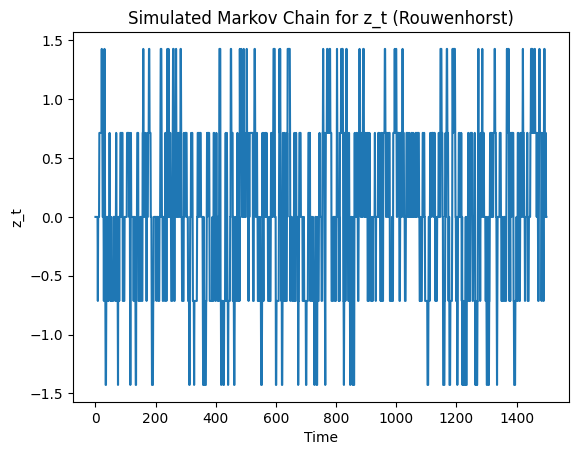

Mean of simulation (Rouwenhorst): 0.021900380514198105
Standard deviation of simulation (Rouwenhorst): 0.7166591751546431
Autocorrelation of simulation (lag 1) (Rouwenhorst): 0.7047508094959661


In [135]:
# Rouwenhorst method 
# here sgima_e =1
std_Z = sqrt(1-rho**2)

# Construct markov chain
def rouwenhorst(N, rho, sigma_epsilon, std_Z):
    p = (1 + rho) / 2 #Becasue zero mean (see slide 38)
    q = p
    s = (1-p) / (2-(p+q))
    psi = sqrt(N-1) * std_Z #See slide 37-39 how to compute
    
    # Initial transition matrix for N=2 #Slide 36
    P = np.array([[p, 1 - p],
                  [1 - q, q]])
    
    # Recursive construction for N>2 #Slide 36
    for n in range(3, N + 1):
        P_new = np.zeros((n, n))
        P_new[:-1, :-1] += p * P
        P_new[:-1, 1:] += (1 - p) * P
        P_new[1:, :-1] += (1 - q) * P
        P_new[1:, 1:] += q * P
        P = P_new / 2
    
    # State space
    z_grid = np.linspace(-psi, psi, N)
    
    return p, s,z_grid, P
 
p, s, z_grid_r, P_r = rouwenhorst(N, rho, sigma_epsilon, std_Z)


# Create table by using function (see below)
dfP = transition_table(z_grid_r, P_r, decimals=4)
print(dfP)

P_r = P_r / P_r.sum(axis=1, keepdims=True) #Nromalize 

# Simulate Markov Chain using Rouwenhorst method
z_sim_r = np.zeros(T)
z_sim_r[0] = Z_1  # Start at the lowest state
cdf_r = np.cumsum(P_r, axis=1)
cdf_r[:, -1] = 1.0
z_sim_r = np.empty(T)
idx = 0

z_sim_r[0] = z_grid_r[idx]
u_r = np.random.rand(T-1)  # in [0,1)
for t in range(1, T):
    idx = np.searchsorted(cdf_r[idx], u_r[t-1], side="right")
    z_sim_r[t] = z_grid_r[idx]
print("Simulated z_t (Rouwenhorst):\n", z_sim_r)

# Discard first 500 observations
z_sim_r = z_sim_r[500:]

# Plot the simulated series
plt.plot(z_sim_r)
plt.title('Simulated Markov Chain for z_t (Rouwenhorst)')
plt.xlabel('Time')
plt.ylabel('z_t')
plt.show()

# Compute statistics for the simulated series
mean_z_sim_r = np.mean(z_sim_r)
std_z_sim_r = np.std(z_sim_r)
autocorr_z_sim_r = np.corrcoef(z_sim_r[:-1], z_sim_r[1:])[0, 1]
print("Mean of simulation (Rouwenhorst):", mean_z_sim_r)
print("Standard deviation of simulation (Rouwenhorst):", std_z_sim_r)
print("Autocorrelation of simulation (lag 1) (Rouwenhorst):", autocorr_z_sim_r)


### Quesiton D
Repeat b and c with different value for rho

## Question 2

### Question a

[[0.36125 0.1275  0.01125]
 [0.1275  0.745   0.1275 ]
 [0.01125 0.1275  0.36125]]
State space for y: [-1.98029509  0.          1.98029509]
State space for z = exp(y): [0.1380285  1.         7.24488053]
                 0.138  1.000   7.245  row_sum
current → next                                
0.138           0.7225  0.255  0.0225      1.0
1.000           0.1275  0.745  0.1275      1.0
7.245           0.0225  0.255  0.7225      1.0
[0.25 0.5  0.25]


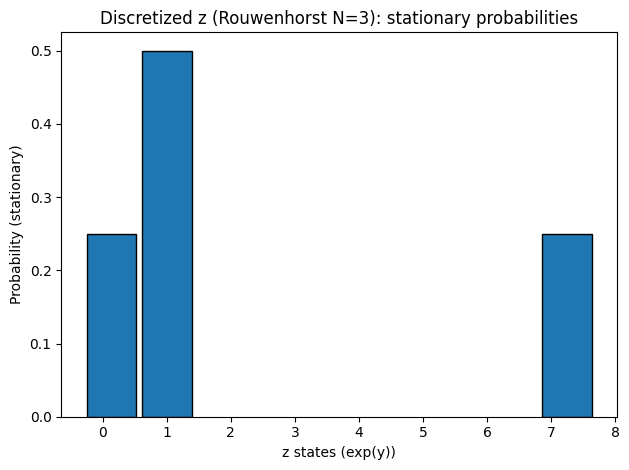

In [136]:
# Strategy: Discredize y and then set z = exp(y) on grid
# Because y still has a symetric distribution but z does not 
sigma_e = 1 
Nz = 3
rho = 0.7 

std_Y = sigma_e / sqrt(1-rho**2)

# Y has zero mean thus can use function from question 1c
p, s, y_grid_r, P_r2 = rouwenhorst(Nz, rho, sigma_e, std_Y)
print(P_r2)

# Transform to z = exp(y)
z_grid_exp = np.exp(y_grid_r)
print("State space for y:", y_grid_r)
print("State space for z = exp(y):", z_grid_exp)

# Create a table for transition probabilities
dfP = transition_table(z_grid_exp, P_r2, decimals=4)
print(dfP)

def stationary_dist_binomial(N, p, q):
    s = (1 - p) / (2 - (p + q))
    pi = np.array([comb(N-1, i) * (s**i) * ((1-s)**(N-1-i)) for i in range(N)], float)
    return pi / pi.sum()

# Example: rho=0.7 
q = p  
pi_cf = stationary_dist_binomial(3, p, q)   
print(pi_cf)

# --- bar width: smaller than nearest spacing to avoid overlap ---
x = np.asarray(z_grid_exp, float)
xs = np.sort(x)
dx = np.diff(xs)
w = 0.9 * dx.min() if dx.size else 0.1

# --- plot ---
plt.figure()
plt.bar(x, pi_cf, width=w, align='center', edgecolor='k')
plt.xlabel('z states (exp(y))')
plt.ylabel('Probability (stationary)')
plt.title('Discretized z (Rouwenhorst N=3): stationary probabilities')
plt.tight_layout()

# Save to folder 
out_dir = Path.cwd() / "output"       
out_dir.mkdir(parents=True, exist_ok=True)
fname = f"Q2a" #Filename 

plt.savefig(out_dir / f"{fname}.png", dpi=300, bbox_inches="tight")
plt.savefig(out_dir / f"{fname}.pdf", bbox_inches="tight")    
plt.show()


### Question b

In [140]:
# Solving the Bellman equation 
beta = 0.9
alpha = 0.3
delta = 0.1
k_stst = ((1-beta + beta*delta)/(alpha*beta))**(1/(alpha-1))
c_stst = k_stst**alpha - delta*k_stst
print("Steady state capital k*:", k_stst)


k_upper = 1.5 * k_stst
k_lower = 0.5 * k_stst
N_k = 100
k_grid = np.linspace(k_lower, k_upper, N_k)

# Create utility function
def utility(c):
    u = np.full_like(c, -np.inf, dtype=float)
    mask = c > 0
    u[mask] = np.log(c[mask])
    return u


# Value function iteration
Nz = len(z_grid_exp)
Nk = len(k_grid)
V  = np.zeros((Nk, Nz))    
V_new = np.empty_like(V)
pol_kp_idx = np.zeros((Nk, Nz), dtype=int)

for iteration in range(1000):
    print(f"Iteration: {iteration}")
    EV = V @ P_r2.T  # Expected value function

    """" Idea: 
        Step1: For each z, we compute the value function over all k and k' pairs and then maximize
        thus given a z we get a Nk * Nk matrix with (k,k') pairs. 
        Step 2: For each pair in the matrix we compute consumption and its utility. 
        We then pick the best column for every row. Thus we get a vector of 
        lenght NK with the best value for each k given z.
        Step 3: We repeat this process for every z and fill the V_new matrix column by column
        Step 4: We continue this process until convergence. 
        
        """""

        

    for iz, z in enumerate(z_grid_exp):
        R = z * k_grid**alpha + (1 - delta) * k_grid # Return (Nk*1) vector for current k and z 
        c = R[:, None] - k_grid[None, :]  # Consumption matrix for all (k,k') pairs
        u = utility(c)  # Utility matrix for all (k,k') pairs
        val = u + beta * EV[:, iz][None, :]  # Total value matrix for all (k,k') pairs

        #Maximize 
        best_idx = np.argmax(val, axis=1) # Index of best k' for each k. Picks the row-wise maximum
        V_new[:, iz] = val[np.arange(Nk), best_idx] # fill the iz-th column of V_new
        pol_kp_idx[:, iz] = best_idx
        kprime_policy = k_grid[pol_kp_idx]

    if np.max(np.abs(V_new - V)) < 1e-6:
        break
    V[:] = V_new

# Euler equation error computation
# Here is take the full grid maximum
""" EEE(k) = log_10 |1-  (c(k'(k)) / ([beta[1+ alpha * E(z') * k'(k)^(alpha-1) - delta]*c(k))) |"""
    
EEE = euler_errors(k_grid, z_grid_exp, P_r2, pol_kp_idx, alpha, beta, delta)
print("max Euler error (log10):", np.nanmax(EEE))



    






Steady state capital k*: 1.6520170257619564
Iteration: 0
Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
Iteration: 21
Iteration: 22
Iteration: 23
Iteration: 24
Iteration: 25
Iteration: 26
Iteration: 27
Iteration: 28
Iteration: 29
Iteration: 30
Iteration: 31
Iteration: 32
Iteration: 33
Iteration: 34
Iteration: 35
Iteration: 36
max Euler error (log10): -0.16910818383607784


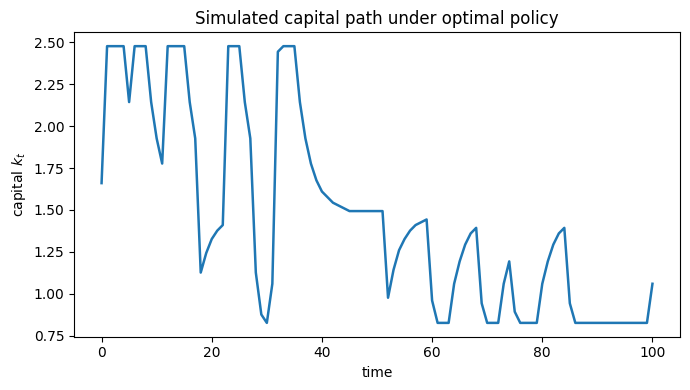

In [ ]:

# --- safety checks / prep ---
P = P_r
assert P.shape == (len(z_grid_exp), len(z_grid_exp)), "P and z_grid_exp size mismatch."
P = P / P.sum(axis=1, keepdims=True)        # guard against tiny row-sum drift

# --- stationary distribution (power method; robust) ---
def stationary_dist(P, tol=1e-12, maxit=100000):
    P = P / P.sum(axis=1, keepdims=True)
    Nz = P.shape[0]
    pi = np.ones(Nz) / Nz
    for _ in range(maxit):
        pi_new = pi @ P
        if np.max(np.abs(pi_new - pi)) < tol:
            pi = pi_new
            break
        pi = pi_new
    return pi / pi.sum()

# --- simulate k path using policy indices ---
def simulate_k_path(k_grid, z_grid, P, pol_kp_idx,
                    T=300, burnin=0, k0=None, z_start="stationary", seed=None):
    rng = np.random.default_rng(seed)
    Nk, Nz = len(k_grid), len(z_grid)

    # row-CDF for z draws
    P = P / P.sum(axis=1, keepdims=True)
    cdf = np.cumsum(P, axis=1)
    cdf[:, -1] = 1.0

    # start k index
    if k0 is None:
        k_idx = int(np.argmin(np.abs(k_grid - np.median(k_grid))))
    else:
        k_idx = int(np.argmin(np.abs(k_grid - k0)))

    # start z index
    if z_start == "stationary":
        pi = stationary_dist(P)
        z_idx = rng.choice(np.arange(Nz), p=pi)
    elif isinstance(z_start, int):
        z_idx = int(np.clip(z_start, 0, Nz-1))
    else:  # float value
        z_idx = int(np.argmin(np.abs(z_grid - float(z_start))))

    # containers
    k_path = np.empty(T+1); k_path[0] = k_grid[k_idx]
    z_path = np.empty(T)

    # simulate
    for t in range(T):
        z_path[t] = z_grid[z_idx]

        # policy: next k' index given current (k,z)
        kp_idx = int(pol_kp_idx[k_idx, z_idx])

        # draw next z
        u = rng.random()
        z_next_idx = int(np.searchsorted(cdf[z_idx], u, side="right"))

        # advance
        k_idx = kp_idx
        z_idx = z_next_idx
        k_path[t+1] = k_grid[k_idx]

    # burn-in (optional)
    if burnin > 0:
        k_path = k_path[burnin:]
        z_path = z_path[burnin:]
    return k_path, z_path

# --- run the simulation with your inputs ---
T = 100
burnin = 0
k0 = k_stst  # start near steady state from your earlier code
k_path, z_path = simulate_k_path(k_grid, z_grid_exp, P, pol_kp_idx,
                                 T=T, burnin=burnin, k0=k0, z_start="stationary", seed=42)

# --- plot: time on x, capital on y ---
plt.figure(figsize=(7,4))
plt.plot(np.arange(len(k_path)), k_path, lw=1.8)
plt.xlabel("time")
plt.ylabel("capital $k_t$")
plt.title("Simulated capital path under optimal policy")
plt.tight_layout()
plt.show()

# (optional) consumption path to sanity-check feasibility:
# c_t = z_t * k_t^alpha + (1 - delta) * k_t - k_{t+1}
c_path = z_path * (k_path[:-1]**alpha) + (1 - delta) * k_path[:-1] - k_path[1:]


# Functions 

In [ ]:
def transition_table(z_grid: np.ndarray, P: np.ndarray, decimals: int = 4):
    """Create a pandas DataFrame representing the transition matrix. """
    # ensure 2D float
    P = np.asarray(P, float)
    z = np.asarray(z_grid)

    P = P / P.sum(axis=1, keepdims=True)

    # label rows/cols by state values
    idx = pd.Index([f"{v:.3f}" if np.issubdtype(z.dtype, np.number) else str(v) for v in z],
                   name="current → next")
    cols = pd.Index([f"{v:.3f}" if np.issubdtype(z.dtype, np.number) else str(v) for v in z])

    df = pd.DataFrame(P, index=idx, columns=cols).round(decimals)

    # add a row-sum check
    df["row_sum"] = df.sum(axis=1).round(decimals)
    return df


import numpy as np

def euler_errors(k_grid, z_grid, P, pol_kp_idx, alpha, beta, delta):
    """
    Return EEE (Nk x Nz) with log10 Euler equation errors at each (k,z).
    Idea: For each (k,z) pair we have the policy function giving k'. Then c can be constructed from k,k',z 
    using expectation over z'. 
    Then we move one step forward using the policy to get k'' and c' from k',z'.
    Then we can compute the Euler equation error.
    """
    P = P / P.sum(axis=1, keepdims=True)            # guard against drift

    Nk, Nz = len(k_grid), len(z_grid)
    EEE = np.full((Nk, Nz), np.nan, dtype=float)    # errors; NaN where infeasible

    k = k_grid
    k_alpha = k**alpha

    for j in range(Nz):                             # current z index
        z = z_grid[j]

        # current resources and chosen k' under policy
        R = z * k_alpha + (1 - delta) * k          # (Nk,)
        kp_idx = pol_kp_idx[:, j]                  # (Nk,)
        kp = k_grid[kp_idx]                        # (Nk,)
        c_t = R - kp                               # (Nk,)

        # next-period objects for ALL possible z' simultaneously
        kp_alpha      = kp**alpha                  # (Nk,)
        kp_alpha_m1   = kp**(alpha - 1)           # (Nk,)

        # policy one more step ahead: k'' given (k', z')
        # shape (Nk, Nz): each column m uses z'_m
        idx_rows = kp_idx[:, None]                 # (Nk,1)
        idx_cols = np.arange(Nz)[None, :]          # (1,Nz)
        kpp_idx = pol_kp_idx[idx_rows, idx_cols]   # (Nk,Nz)
        kpp = k_grid[kpp_idx]                      # (Nk,Nz)

        # consumption next period for each z'
        c_next = (z_grid[None, :] * kp_alpha[:, None]
                  + (1 - delta) * kp[:, None] - kpp)   # (Nk,Nz)

        # marginal utilities next period (handle infeasible c_next <= 0)
        with np.errstate(divide='ignore', invalid='ignore'):
            uc_next = 1.0 / c_next                 # (Nk,Nz)

        # gross return term for each z'
        gross = (1 - delta) + alpha * z_grid[None, :] * kp_alpha_m1[:, None]  # (Nk,Nz)

        # expectation over z' using row j of P
        term = gross * uc_next                     # (Nk,Nz)
        Et_term = term @ P[j, :]                   # (Nk,)

        # implied c_t from Euler equation: c_hat = 1 / (beta * Et_term)
        with np.errstate(divide='ignore', invalid='ignore'):
            c_hat = 1.0 / (beta * Et_term)        # (Nk,)

        # EEE = log10 | 1 - c_hat / c_t |
        valid = (c_t > 0) & np.isfinite(c_hat) & (c_hat > 0)
        errs = np.empty(Nk); errs[:] = np.nan
        errs[valid] = np.log10(np.abs(1.0 - c_hat[valid] / c_t[valid]))
        EEE[:, j] = errs

    return EEE
